## CART (Classification and Regression Trees) Nedir? 

<img src="https://scikit-learn.org/stable/_images/sphx_glr_plot_tree_classification_001.png" width="500"/>

**CART**, yani *Classification and Regression Trees* (Sınıflandırma ve Regresyon Ağaçları), veriyi anlamak ve karar vermek için kullanılan bir algoritmadır. İsmi kafa karıştırıcı olabilir ama aslında mantığı çok basit: Elimizdeki veriyi sorular sorarak dallara ayırır, en sonunda bir karar veririz.

### 1. Karar Ağacı Nedir?

- **Karar Ağacı**, tıpkı aile soy ağacı gibi dallanarak ilerleyen bir yapıdır.
- Her bir “düğüm” (nokta), bir sorudur. Cevaba göre farklı yollara ayrılır.
- Ağacın “kökü” en baştaki, başlangıç sorusudur.
- “İç düğümler” (ara noktalar), veriyi bölmeye devam eden sorulardır.
- “Yaprak düğümler” ise artık karar verilen, nihai sonuca ulaşan uç noktalar.

![Karar Ağacı Örneği](https://upload.wikimedia.org/wikipedia/commons/f/f3/CART_tree_titanic_survivors.png)

### 2. Sınıflandırma vs Regresyon Ağacı

- **Sınıflandırma Ağacı**: Sonuç, bir kategori olur (örneğin “evet/hayır”, “hasta/sağlıklı” gibi).
- **Regresyon Ağacı**: Sonuç, bir sayı (örneğin “fiyat”, “puan”, “yaş” gibi).

| Tür             | Sonuç Tipi    | Örnek                                   |
|-----------------|--------------|-----------------------------------------|
| Sınıflandırma   | Kategori     | Kişi hasta mı? (Evet/Hayır)             |
| Regresyon       | Sayı         | Evin fiyatı kaç TL?                     |

---

### 3. Nasıl Çalışır? — En Basit Dille

1. **Bölme:** En iyi “ayraç” (özellik ve değer) bulunur. Tıpkı “Yaşı 18’den büyük mü?” diye sormak gibi.
2. **Dallanma:** Cevaba göre veriler ikiye ayrılır, her “dalda” bu şekilde sorular sorulmaya devam eder.
3. **Durdurma:** Artık bölecek anlamlı bir şey kalmadığında dalın ucu “yaprak” olur, orada tahmin yapılır.

#### Sınıflandırmada neye göre böler?
- “Gini impurity” veya “Entropi” diye adlandırılan değerlerle, gruplaşma ne kadar saf/temizse (hepsi aynı sınıf) orası tercih edilir.

#### Regresyonda neye göre böler?
- Varyansın (değerlerin farklılığı) en aza indiği bölünmeler seçilir.

---

### 4. Karar Ağaçlarının Artıları (Neden Kullanılır?)

- **Çok kolay yorumlanır!** Ne yaptığı, nasıl karar verdiği belli olur.
- **Veriyi özel olarak ölçeklendirmek gerekmez.**
- **Karmaşık ön işleme ihtiyacı yoktur.**
- **Hem sınıflandırma hem de regresyon işini başarır.**
- **Küçük ve orta boy verilerde çok hızlıdır.**

---

### 5. Karar Ağaçlarının Eksileri (Dikkat Edilmesi Gerekenler)

- **Aşırıya Kaçabilir!** Çok dallanırsa, her detayı öğrenir ve yeni veride başarısı düşebilir. Buna "overfitting" denir.
- **Hassastır.** Küçük bir veri değişikliğinde ağaç bambaşka şekil alabilir.
- **Tek başına çoğu zaman yeterli güçlü değildir.** O yüzden “Random Forest” veya “Boosting” gibi yöntemlerle çoğaltılıp güçlendirilir.

---

### 6. Nerede Kullanılır?

- Kredi başvurusu değerlendirme
- Müşterileri gruplara ayırmak (segmentasyon)
- Hastalık teşhisi ve risk analizi
- Fiyat/satış tahmini
- Anket ve veri analizinde

---

### 7. Özet ve Ekstra Görseller

Kısacası, karar ağacı (CART), verileri “soru-cevap” mantığıyla ayırıp en sonunda bir karar veren, kolay anlaşılan, güçlü bir algoritmadır. Modern makine öğrenmesinin temel taşlarındandır!




In [26]:
# Gerekli kütüphaneleri içe aktarıyoruz ve her birinin ne işe yaradığını açıklıyoruz:

import warnings                # Uyarı mesajlarını yönetmek/gizlemek için kullanılır.
import joblib                  # Modelleri kaydetmek ve tekrar yüklemek için kullanılır.
import pydotplus               # Karar ağaçlarını grafik olarak çizmek/çıkarmak için kullanılır.
import numpy as np             # Sayısal işlemler için temel matematik fonksiyonlarını içerir (örn. diziler, matrisler).
import pandas as pd            # Veri okuma, düzenleme ve tablo biçiminde veri analizi için kullanılır.
import seaborn as sns          # Grafik ve görselleştirme işlemleri için kullanılır (özellikle istatistiksel grafikler).
from matplotlib import pyplot as plt   # Grafik çizimi için kullanılan en popüler kütüphanelerden biri.
from sklearn.tree import DecisionTreeClassifier, export_graphviz, export_text
# DecisionTreeClassifier: Karar ağacı modeli kurmak için.
# export_graphviz: Karar ağacını görselleştirmek için grafik formatında dışarı aktarmak için.
# export_text: Karar ağacının kural setini metin olarak dışarı aktarmak için.

from sklearn.metrics import classification_report, roc_auc_score
# classification_report: Modelin sınıflandırma performans raporunu üretmek için.
# roc_auc_score: ROC eğrisi altında kalan alanı (AUC) hesaplamak için, modelin başarısını ölçer.

from sklearn.model_selection import train_test_split, GridSearchCV, cross_validate, validation_curve
# train_test_split: Veriyi eğitim ve test olarak ayırmak için.
# GridSearchCV: Hiperparametre optimizasyonu için (farklı parametre kombinasyonlarını deneyerek en iyisini bulma).
# cross_validate: Modelin farklı metriklerine cross-validation uygulamak için.
# validation_curve: Modelin parametrelerine göre doğrulama eğrilerinin çıkarılması için.

from skompiler import skompile # Sklearn modellerini farklı kod dillerine çevirmek için (örneğin Python, SQL).
import graphviz                # Karar ağaçlarını çizmek veya görselleştirmek için kullanılır.

pd.set_option('display.max_columns', None) # Pandas DataFrame'lerde tüm sütunların görünmesini sağlar.
pd.set_option('display.width', 500)        # Konsolda tablo genişliğini ayarlamak için.

warnings.simplefilter(action='ignore', category=Warning) # Uyarı mesajlarını sessize alır.

### Modelleme

In [27]:
# 1. Veri setini yüklüyoruz. pd.read_csv fonksiyonu ile "datasets/diabetes.csv" dosyasını okuyoruz
df = pd.read_csv("datasets/diabetes.csv") 

# 2. Hedef değişkeni (Outcome) y olarak belirliyoruz. Bu değişken diyabet olup olmadığını ifade ediyor.
y = df["Outcome"] 

# 3. Girdi (özellik) değişkenlerini (bağımsız değişkenler) X olarak ayırıyoruz. Outcome değişkeni hariç tüm sütunlar X'te olacak.
X = df.drop("Outcome", axis=1) 

# 4. DecisionTreeClassifier (CART) algoritmasını kullanarak modeli oluşturuyoruz ve veriye fit ediyoruz.
# random_state=1: Sonuçların tekrar üretilebilir olmasını sağlar (seed gibi düşünün).
cart_model = DecisionTreeClassifier(random_state=1).fit(X, y)

In [28]:
# Modelin tahminlerini y_pred'e atıyoruz. Bu satırda, daha önce oluşturup veriye fit ettiğimiz karar ağacı modelini (cart_model), giriş değişkenleri X üzerinde predict fonksiyonu ile kullanıyoruz.
# Bu işlem sonucunda, model X verileri için tahmin ettiği (0 veya 1) sınıf etiketlerini üretir ve y_pred adlı değişkene atar. 
y_pred = cart_model.predict(X)

In [29]:
# Modelin, her gözlem için 1 (pozitif sınıf) olma olasılığını tahmin etmesini istiyoruz.
# predict_proba(X) fonksiyonu, her sınıf için olasılık döndürür: [:, 1] ile 1 sınıfının (yani "diyabet var" olasılığı) olasılık değerlerini alıyoruz.
y_prob = cart_model.predict_proba(X)[:, 1]

In [30]:
print(classification_report(y, y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       500
           1       1.00      1.00      1.00       268

    accuracy                           1.00       768
   macro avg       1.00      1.00      1.00       768
weighted avg       1.00      1.00      1.00       768



In [31]:
roc_auc_score(y, y_prob)

1.0

#### Holdout Yöntemi ile Başarı Değerlendirme


In [32]:
# 1. Verimizi eğitim ve test olarak ikiye bölelim. %30 test, %70 train.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=45)

# 2. Eğitim verisi ile CART modelini fit edelim. random_state=17: Sonuçların tekrar üretilebilir olmasını sağlar. fit fonksiyonu, eğitim verilerini kullanarak modeli oluşturur.
cart_model = DecisionTreeClassifier(random_state=45).fit(X_train, y_train)

# 3. Eğitim seti üzerindeki hata metriklerini hesaplayalım.
# Eğitim verisi için tahminler: predict fonksiyonu, eğitim verileri üzerinde tahmin yapar.
y_pred_train = cart_model.predict(X_train)
# Eğitim verisi için olasılıklar (pozitif sınıf olasılığı): predict_proba fonksiyonu, eğitim verileri üzerinde olasılık tahmini yapar.  
y_prob_train = cart_model.predict_proba(X_train)[:, 1]
# Eğitim verisi için sınıflandırma raporu: classification_report fonksiyonu, eğitim verileri üzerinde sınıflandırma raporu oluşturur.
print("Train Classification Report:\n", classification_report(y_train, y_pred_train))
# Eğitim verisi için ROC AUC değeri: roc_auc_score fonksiyonu, eğitim verileri üzerinde ROC AUC değeri hesaplar.
print("Train ROC AUC:", roc_auc_score(y_train, y_prob_train))
print("--------------------------------")
# 4. Test seti üzerindeki hata metriklerini hesaplayalım.
# Test verisi için tahminler: predict fonksiyonu, test verileri üzerinde tahmin yapar.
y_pred_test = cart_model.predict(X_test)
# Test verisi için olasılıklar (pozitif sınıf olasılığı): predict_proba fonksiyonu, test verileri üzerinde olasılık tahmini yapar.
y_prob_test = cart_model.predict_proba(X_test)[:, 1]
# Test verisi için sınıflandırma raporu: classification_report fonksiyonu, test verileri üzerinde sınıflandırma raporu oluşturur.
print("Test Classification Report:\n", classification_report(y_test, y_pred_test))
# Test verisi için ROC AUC değeri: roc_auc_score fonksiyonu, test verileri üzerinde ROC AUC değeri hesaplar.
print("Test ROC AUC:", roc_auc_score(y_test, y_prob_test))

Train Classification Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00       346
           1       1.00      1.00      1.00       191

    accuracy                           1.00       537
   macro avg       1.00      1.00      1.00       537
weighted avg       1.00      1.00      1.00       537

Train ROC AUC: 1.0
--------------------------------
Test Classification Report:
               precision    recall  f1-score   support

           0       0.75      0.78      0.77       154
           1       0.53      0.49      0.51        77

    accuracy                           0.68       231
   macro avg       0.64      0.64      0.64       231
weighted avg       0.68      0.68      0.68       231

Test ROC AUC: 0.6363636363636364


#### CV ile Başarı Değerlendirme


In [33]:
# 1. Önce bir karar ağacı (CART) modeli oluşturuyoruz.
# random_state=17 yazınca, her çalıştırmada aynı sonucu alırız (tesadüfilik önlenir).
cart_model = DecisionTreeClassifier(random_state=17).fit(X, y)

# 2. Modelimizin başarısını daha doğru ölçmek için cross_validate (çapraz doğrulama) kullanıyoruz.
# Burada veriyi 5 parçaya bölüyoruz (cv=5): 
# Her seferinde bu parçalardan biri test, geri kalanı eğitim verisi oluyor. Bu işlem 5 kez tekrar ediyor.
# scoring=["accuracy", "f1", "roc_auc"] diyerek:
# - Doğruluk (accuracy): Kaç tanesini doğru tahmin etmişiz?
# - F1 skoru (f1): Doğruluk ve hassasiyetin dengesi, dengesiz veri için önemli.
# - ROC AUC: Modelin pozitif ve negatifleri ayırabilme gücünü ölçer.
cv_results = cross_validate(cart_model,
                            X, y,
                            cv=5,  # 5 katlı çapraz doğrulama (her parçayla test yapılır)
                            scoring=["accuracy", "f1", "roc_auc"])

# 3. Sonuçları hesaplayıp yazdırıyoruz:
# Burada .mean() fonksiyonu ile 5 ayrı sonucun ortalamasını alıyoruz.
print("Çapraz Doğrulama (CV) ile Ortalama Doğruluk:", cv_results['test_accuracy'].mean())
print("Çapraz Doğrulama (CV) ile Ortalama F1 skoru:", cv_results['test_f1'].mean())
print("Çapraz Doğrulama (CV) ile Ortalama ROC AUC:", cv_results['test_roc_auc'].mean())

# Kısacası: 
# Modeli veriye uyduruyoruz. Sonra modeli 5 defa farklı parçalarda test ediyoruz. 
# Her testin sonucunu alıp, ortalamasını hesaplıyor ve baştan savma değil, güvenilir bir başarı ölçümü elde ediyoruz.


Çapraz Doğrulama (CV) ile Ortalama Doğruluk: 0.7058568882098294
Çapraz Doğrulama (CV) ile Ortalama F1 skoru: 0.5710621194523633
Çapraz Doğrulama (CV) ile Ortalama ROC AUC: 0.6719440950384347


### Hyperparameter Optimization with GridSearchCV

In [34]:
# Hiperparametre Optimizasyonu (GridSearchCV ile)

# Bir karar ağacı modelinin başarısı, ona verdiğimiz bazı ayarlara (ör: maksimum derinlik, bir dalı ayırmak için gereken minimum veri sayısı gibi) çok bağlıdır.
# Bu ayarlara "hiperparametre" denir. Düzgün seçilmediğinde model ya öğrenemez ya da aşırı ezberler.
# Peki en iyi hangi ayarlarla çalışır? Bunun için GridSearchCV kullanılır:
# GridSearchCV, vermemizi istediğimiz parametre aralıklarını tek tek dener, çapraz doğrulama ile hangi ayarın en iyi sonucu verdiğini bulur.

# Önce bakacağımız hiperparametrelerin aralığını tanımlıyoruz:
cart_params = {
    'max_depth': range(1, 11),           # Ağacın ne kadar derin olabileceği: 1'den 10'a kadar dene
    "min_samples_split": range(2, 20)    # Bir düğümü bölecek minimum örnek sayısı: 2'den 19'a kadar dene
}

# GridSearchCV başlatılırken:
# - cart_model: Üzerinde ayar yapacağımız karar ağacı modeli
# - cart_params: Denenecek ayarların sözlüğü
# - cv=5: 5 katlı çapraz doğrulama kullan
# - n_jobs=-1: Tüm işlemcileri kullanarak hızlıca dene
# - verbose=1: Süreç sırasında ekrana bilgi yaz
cart_best_grid = GridSearchCV(cart_model,
                             cart_params,
                             cv=5,
                             n_jobs=-1,
                             verbose=1).fit(X, y)

# En iyi parametre kombinasyonu hangisiymiş?
print("En İyi Parametreler:", cart_best_grid.best_params_)

# En iyi skoru kaç bulmuş?
print("En İyi Skor (CV ortalaması):", cart_best_grid.best_score_)

# Rastgele bir satıra, en iyi bulduğu modelin tahmini nedir?
random = X.sample(1, random_state=45)
print("Rastgele bir gözlemde modelin tahmini:", cart_best_grid.predict(random))

Fitting 5 folds for each of 180 candidates, totalling 900 fits
En İyi Parametreler: {'max_depth': 5, 'min_samples_split': 12}
En İyi Skor (CV ortalaması): 0.7500806383159324
Rastgele bir gözlemde modelin tahmini: [1]


### Final Model

In [35]:
 # Final Model (Son Model)

# GridSearchCV kullanarak en iyi ayarları (hiperparametreleri) bulmuştuk.
# Şimdi, bu en iyi ayarlarla modelimizi tüm veri üzerinde yeniden kuruyoruz.
# Böylece, modelimiz hem ezberleme riskini azaltmış hem de elimizdeki en iyi sonuçları verecek şekilde ayarlanmış oluyor.

# 1. En iyi parametrelerle karar ağacı modelini yeniden oluştur ve tüm veriye uygula:
cart_final = DecisionTreeClassifier(**cart_best_grid.best_params_, random_state=17).fit(X, y)

# 2. Modelin hangi ayarlarla çalıştığına bakalım:
print("Final Model Parametreleri:", cart_final.get_params())

# 3. Modelin çapraz doğrulamadaki (cv=5) başarılarını da ölçebiliriz:
cv_results = cross_validate(cart_final,
                            X, y,
                            cv=5,
                            scoring=["accuracy", "f1", "roc_auc"])

# Ortalamaları ekrana yazdıralım:
print("Doğruluk (Accuracy):", cv_results['test_accuracy'].mean())
print("F1 Skoru:", cv_results['test_f1'].mean())
print("ROC-AUC:", cv_results['test_roc_auc'].mean())

# Artık modelimiz, en iyi ayarlarla kurulmuş ve başarı oranlarını biliyoruz.;

Final Model Parametreleri: {'ccp_alpha': 0.0, 'class_weight': None, 'criterion': 'gini', 'max_depth': 5, 'max_features': None, 'max_leaf_nodes': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 12, 'min_weight_fraction_leaf': 0.0, 'monotonic_cst': None, 'random_state': 17, 'splitter': 'best'}
Doğruluk (Accuracy): 0.7500806383159324
F1 Skoru: 0.6161442661552334
ROC-AUC: 0.8000573025856046


### Feature Importance

Özellik (Feature) Önem Düzeyleri: [0.01139589 0.49879295 0.04237811 0.         0.01510703 0.22415144
 0.06879392 0.13938066]


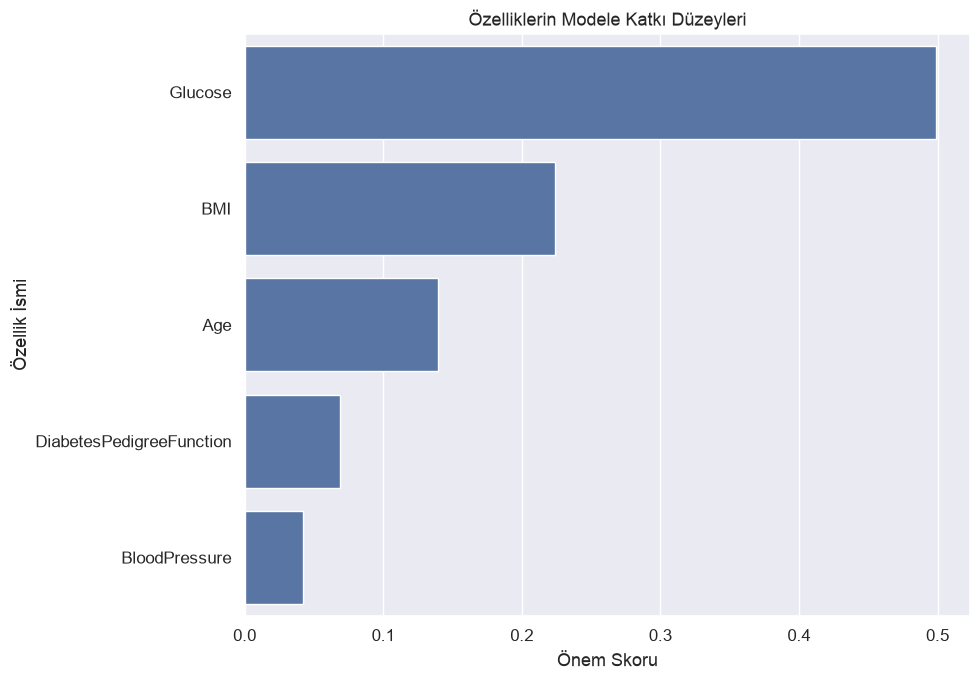

In [36]:
# Karar ağacı modeli, hangi değişkenlerin (özelliklerin) sonucu tahmin ederken daha önemli olduğunu gösterebilir.
# Bunu 'feature_importances_' özelliği ile görebiliriz.
print("Özellik (Feature) Önem Düzeyleri:", cart_final.feature_importances_)

# Şimdi, bu önem düzeylerini daha anlaşılır olması için bir grafikle görselleştirelim.
# Aşağıdaki fonksiyon, modelin hangi değişkenlere (sütunlara) daha fazla önem verdiğini grafikle gösterir.
def plot_importance(model, features, num=None, save=False):
    # model: Eğittiğimiz karar ağacı modeli
    # features: Bağımsız değişkenleri içeren veri (X)
    # num: Kaç özellik gösterilsin? Varsayılan: Tüm özellikler
    if num is None:
        num = len(features.columns)
    # Özelliklerin önem skorlarını al
    feature_imp = pd.DataFrame({
        'Önem Skoru': model.feature_importances_,
        'Özellik İsmi': features.columns
    })
    # En önemli (en yüksek skorlu) değişkenleri yukarıda göstermek için sırala
    feature_imp = feature_imp.sort_values(by="Önem Skoru", ascending=False)
    # Grafiği oluştur
    plt.figure(figsize=(10, 7))
    sns.set(font_scale=1.1)
    # Sadece en önemli 'num' kadar özelliği çizdir
    sns.barplot(x="Önem Skoru", y="Özellik İsmi", data=feature_imp.iloc[:num])
    plt.title('Özelliklerin Modele Katkı Düzeyleri')
    plt.tight_layout()
    plt.show()
    # Eğer grafiği dosya olarak kaydetmek istersek:
    if save:
        plt.savefig('importances.png')

# Fonksiyonu çağırıyoruz. Mesela en önemli 5 özelliği görmek isteyelim:
plot_importance(cart_final, X, num=5)

### Analyzing Model Complexity with Learning Curves (BONUS)

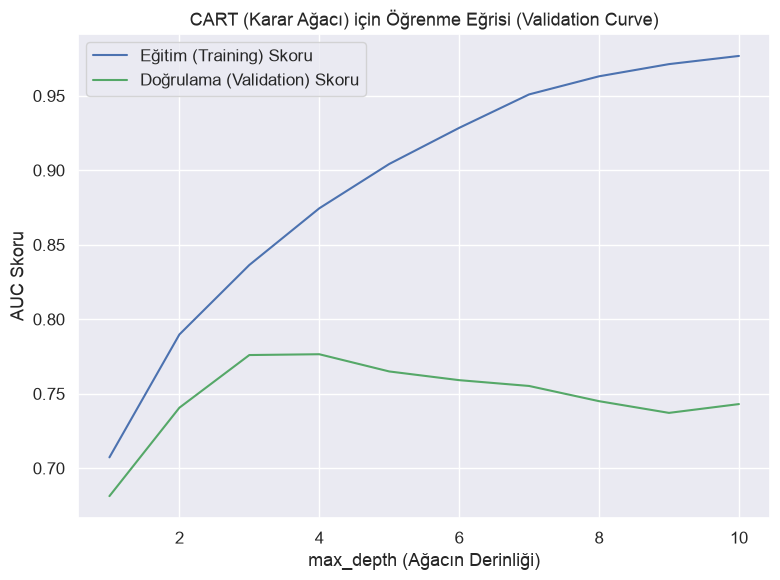

In [37]:
# Modelin karmaşıklığını ve aşırı/az öğrenme durumlarını görselleştirmek için "öğrenme eğrisi" (validation curve) çiziyoruz. 
# Şimdi adım adım gidelim:

# 1. Adım: validation_curve fonksiyonu ile farklı max_depth (ağacın derinliği) değerleri için eğitim ve doğrulama skorlarını hesaplıyoruz.
train_score, test_score = validation_curve(
    estimator=cart_final,                     # Kullandığımız model (karar ağacı)
    X=X,                                      # Bağımsız değişkenler (özellikler)
    y=y,                                      # Bağımlı değişken (hedef)
    param_name="max_depth",                   # Hiperparametremiz: max_depth (ağacın derinliği)
    param_range=range(1, 11),                 # 1'den 10'a kadar derinlikleri dene
    scoring="roc_auc",                        # Değerlendirme metriği olarak AUC değerini kullan
    cv=10                                     # 10 katlı çapraz doğrulama
)

# 2. Adım: Her derinlik değeri için eğitim ve doğrulama skorlarının ortalamasını alıyoruz.
mean_train_score = np.mean(train_score, axis=1)
mean_test_score = np.mean(test_score, axis=1)

# 3. Adım: Sonuçları grafikle görselleştiriyoruz.
plt.figure(figsize=(8, 6))

# Eğitim verisindeki skorları (modelin kendi gördüğü veriye ne kadar iyi uyduğunu gösterir) mavi renk ile çiziyoruz.
plt.plot(range(1, 11), mean_train_score,
         label="Eğitim (Training) Skoru", color='b')

# Test (doğrulama) verisindeki skorları (model yeni veride nasıl) yeşil renk ile çiziyoruz.
plt.plot(range(1, 11), mean_test_score,
         label="Doğrulama (Validation) Skoru", color='g')

# Grafik başlık ve eksen isimleri ekleyelim.
plt.title("CART (Karar Ağacı) için Öğrenme Eğrisi (Validation Curve)")
plt.xlabel("max_depth (Ağacın Derinliği)")
plt.ylabel("AUC Skoru")

plt.tight_layout()
plt.legend(loc='best')
plt.show()


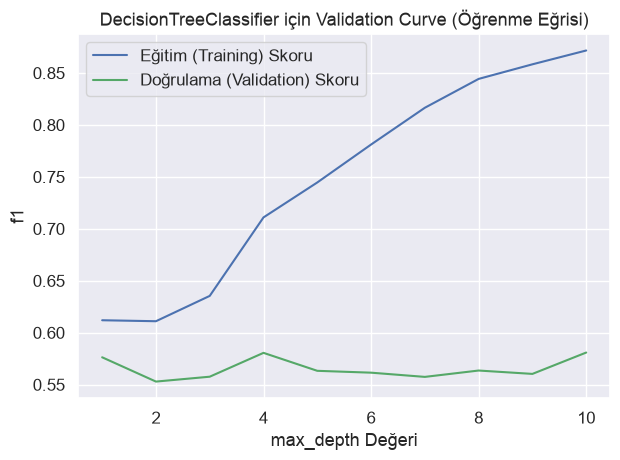

In [38]:
def val_curve_params(model, X, y, param_name, param_range, scoring="roc_auc", cv=10):
    """
    Bir modelin belirli bir hiperparametresi için eğitim ve doğrulama skorlarının öğrenme eğrisini çizmek için kullanılır.
    Bu fonksiyonun adımlarını aşağıda tek tek açıklıyoruz:
    """
    # 1. Adım: Seçilen hiperparametre (ör: max_depth) için belirtilen değer aralığında 
    # eğitim ve doğrulama seti üzerindeki skorları hesapla.
    train_score, test_score = validation_curve(
        model, 
        X=X, 
        y=y, 
        param_name=param_name, 
        param_range=param_range, 
        scoring=scoring, 
        cv=cv
    )

    # 2. Adım: Farklı hiperparametre değerleri için elde edilen eğitim ve doğrulama skorlarının ortalamasını al.
    mean_train_score = np.mean(train_score, axis=1)
    mean_test_score = np.mean(test_score, axis=1)

    # 3. Adım: Ortalama eğitim skorlarını ve doğrulama skorlarını çizgi grafiği olarak görselleştir.
    plt.plot(param_range, mean_train_score, label="Eğitim (Training) Skoru", color='b')
    plt.plot(param_range, mean_test_score, label="Doğrulama (Validation) Skoru", color='g')

    # 4. Adım: Grafik başlığı, eksen adları ve efsane (legend) ekle.
    plt.title(f"{type(model).__name__} için Validation Curve (Öğrenme Eğrisi)")
    plt.xlabel(f"{param_name} Değeri")
    plt.ylabel(f"{scoring}")
    plt.tight_layout()
    plt.legend(loc='best')

    # 5. Adım: Grafiği göster.
    plt.show(block=True)

# Örnek kullanım: cart_final modeli için max_depth parametresiyle "f1" skoru üzerinden validation curve çiziyoruz.
val_curve_params(cart_final, X, y, "max_depth", range(1, 11), scoring="f1")

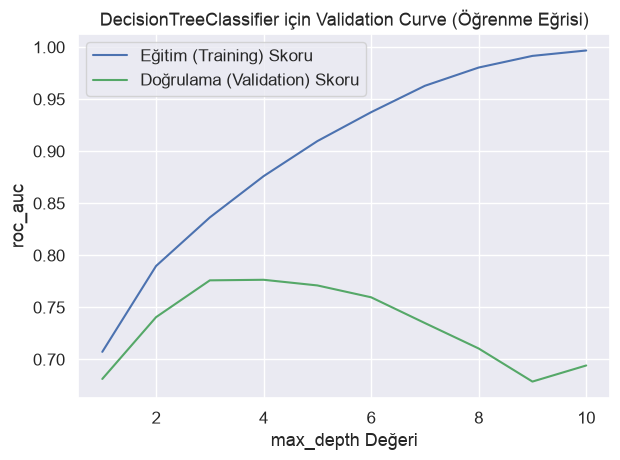

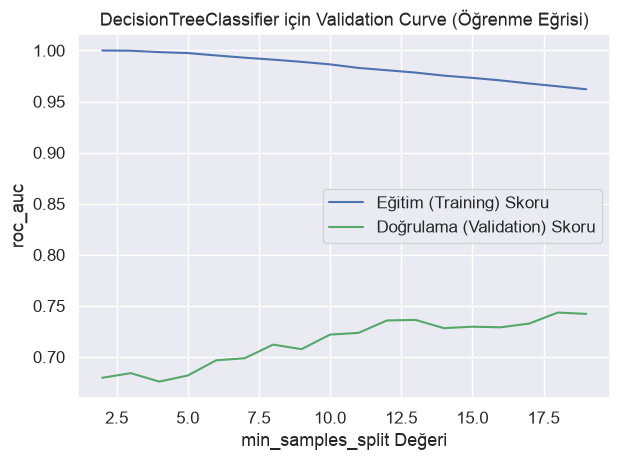

In [39]:
cart_val_params = [["max_depth", range(1, 11)], ["min_samples_split", range(2, 20)]]

for i in range(len(cart_val_params)):
    val_curve_params(cart_model, X, y, cart_val_params[i][0], cart_val_params[i][1])


### Visualizing the Decision Tree

Graphviz/pydotplus kullanılamıyor, matplotlib ile ağaç çiziliyor. Hata mesajı: GraphViz's executables not found


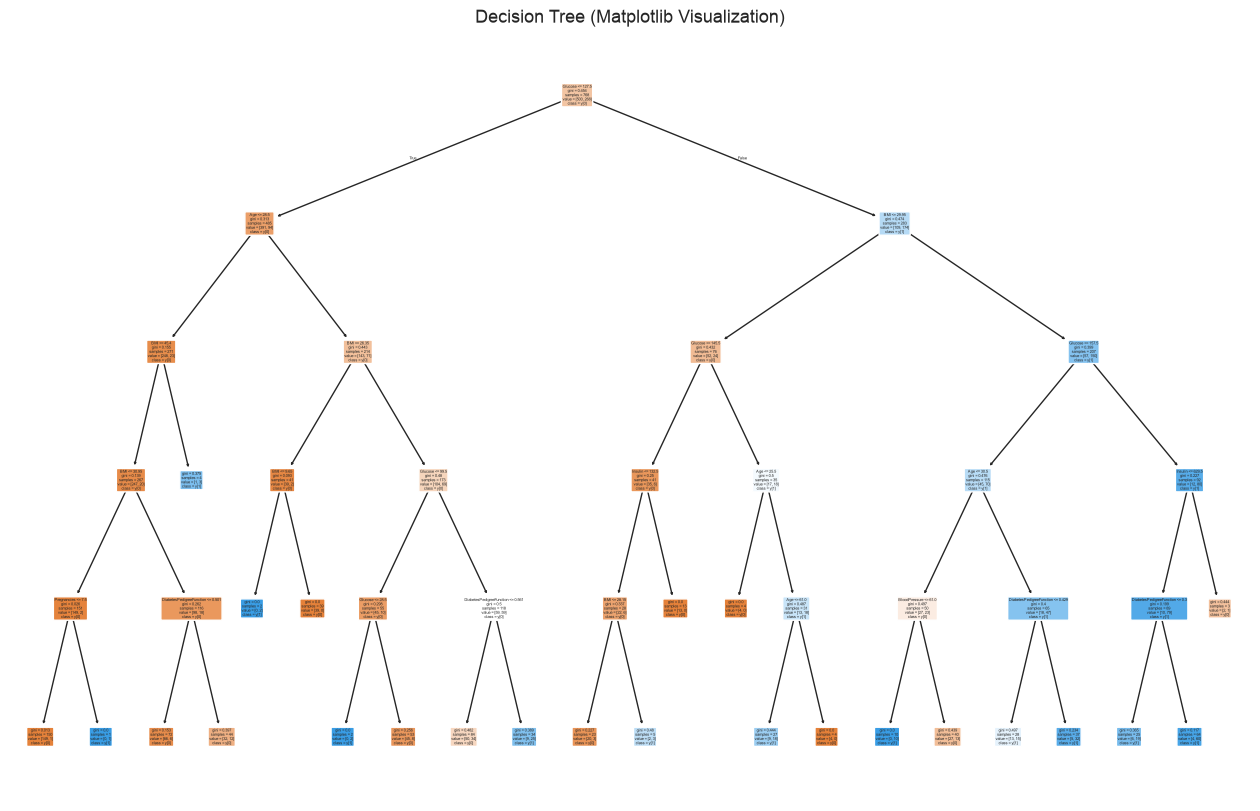

Ağaç, matplotlib ile görselleştirildi.


In [40]:
# Adım adım karar ağacı görselleştirme: Hem pydotplus/graphviz hem de matplotlib alternatifi ile. 
# Kütüphane kurulumu yoksa otomatik olarak matplotlib ile devam eder.

# 1. Gerekli paketleri import edelim.
from sklearn.tree import export_graphviz
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

# 2. Görselleştirme fonksiyonumuzu tanımlayalım.
def tree_graph(model, col_names, file_name=None):
    # 3. Önce pydotplus ve graphviz yolunu deneyelim:
    try:
        import pydotplus
        # 4. Modeli .dot formatında ifade et.
        tree_str = export_graphviz(model, feature_names=col_names, filled=True, out_file=None)
        # 5. .dot stringinden grafik objesi oluştur.
        graph = pydotplus.graph_from_dot_data(tree_str)
        # 6. Eğer çıktı olarak dosya ismi verilmişse PNG olarak kaydet.
        if file_name is not None:
            graph.write_png(file_name)
            print("Ağaç, pydotplus+graphviz ile PNG olarak kaydedildi.")
        else:
            # 7. Eğer dosya ismi verilmemişse resmi notebookta göster.
            from PIL import Image
            import io
            img = Image.open(io.BytesIO(graph.create_png()))
            plt.imshow(img)
            plt.axis('off') # Eksenleri gizle
            plt.show()
            print("Ağaç, pydotplus+graphviz ile görselleştirildi.")
    # 8. Eğer hata olursa, matplotlib ile devam et:
    except Exception as e:
        print("Graphviz/pydotplus kullanılamıyor, matplotlib ile ağaç çiziliyor. Hata mesajı:", e)
        plt.figure(figsize=(16, 10))
        # 9. sklearn ile doğrudan plot_tree fonksiyonu ile çizim
        plot_tree(model, feature_names=col_names, filled=True, rounded=True, class_names=True)
        plt.title("Decision Tree (Matplotlib Visualization)")
        plt.show()
        print("Ağaç, matplotlib ile görselleştirildi.")

# 10. Fonksiyonu kullanarak karar ağacını çizdirelim:
tree_graph(model=cart_final, col_names=X.columns, file_name=None)

In [41]:
cart_final.get_params()


{'ccp_alpha': 0.0,
 'class_weight': None,
 'criterion': 'gini',
 'max_depth': 5,
 'max_features': None,
 'max_leaf_nodes': None,
 'min_impurity_decrease': 0.0,
 'min_samples_leaf': 1,
 'min_samples_split': 12,
 'min_weight_fraction_leaf': 0.0,
 'monotonic_cst': None,
 'random_state': 17,
 'splitter': 'best'}

### Extracting Decision Rules


In [42]:
# export_text fonksiyonu ile; eğittiğimiz karar ağacındaki dallanma, koşul ve sonuçların insan tarafından okunabilir metin olarak çıkarım kurallarını alıyoruz.
tree_rules = export_text(cart_final, feature_names=list(X.columns))  # Ağacın kurallarını metin olarak alıyoruz.
print(tree_rules)  # Çıkarılan karar kurallarını ekrana yazdırıyoruz.

# Açıklama:
# - export_text, karar ağacının kökten yapraklara tüm karar noktalarını (koşulları, değişken isimleriyle birlikte) yazılı olarak gösterir.
# - Her satırda bir node'un koşulu bulunur. İçe doğru gelen boşluklar, o koşulun ağaçtaki seviyesini gösterir.
# - Buradan, veri hangi koşullara göre hangi sonuca karar veriyor anlayabiliriz.

|--- Glucose <= 127.50
|   |--- Age <= 28.50
|   |   |--- BMI <= 45.40
|   |   |   |--- BMI <= 30.95
|   |   |   |   |--- Pregnancies <= 7.50
|   |   |   |   |   |--- class: 0
|   |   |   |   |--- Pregnancies >  7.50
|   |   |   |   |   |--- class: 1
|   |   |   |--- BMI >  30.95
|   |   |   |   |--- DiabetesPedigreeFunction <= 0.50
|   |   |   |   |   |--- class: 0
|   |   |   |   |--- DiabetesPedigreeFunction >  0.50
|   |   |   |   |   |--- class: 0
|   |   |--- BMI >  45.40
|   |   |   |--- class: 1
|   |--- Age >  28.50
|   |   |--- BMI <= 26.35
|   |   |   |--- BMI <= 9.65
|   |   |   |   |--- class: 1
|   |   |   |--- BMI >  9.65
|   |   |   |   |--- class: 0
|   |   |--- BMI >  26.35
|   |   |   |--- Glucose <= 99.50
|   |   |   |   |--- Glucose <= 28.50
|   |   |   |   |   |--- class: 1
|   |   |   |   |--- Glucose >  28.50
|   |   |   |   |   |--- class: 0
|   |   |   |--- Glucose >  99.50
|   |   |   |   |--- DiabetesPedigreeFunction <= 0.56
|   |   |   |   |   |--- class: 0

### Extracting Python Codes of Decision Rules

In [46]:
# skompile kütüphanesini kullanarak, eğitilmiş karar ağacı modelimizin aldığı kararları farklı ortamlarda tekrar edebilecek kodlara dönüştürebiliriz. 
# Ancak, skompile paketinin mevcut sürümü Python 3.8+ üzerinde çalışırken, 'ast.Num' kullanımı nedeniyle Python 3.10+ sürümlerinde hata verir.
# Aşağıdaki kod bloğu, bu hatayı yönetmek ve kullanıcıya anlamlı bir geri bildirim sunmak için try-except ile sarılmıştır.

try:
    # 1. Modelin kurallarını Python koduna döker:
    print(skompile(cart_final.predict).to('python/code'))  # Python'da kural ifadelendirmesi

    # 2. Modelin kurallarını SQL biçimine çevirir:
    print(skompile(cart_final.predict).to('sqlalchemy/sqlite'))  # SQL (SQLite uyumlu) kural ifadelendirmesi

    # 3. Modelin kararlarını Excel'e döker, böylece Excel formülü şeklinde de kullanılabilir:
    print(skompile(cart_final.predict).to('excel'))  # Excel fonksiyonu olarak model karar kuralları

    # Böylece, karar ağacımızın mantığını farklı platformlarda veya üretim ortamlarında kolayca kullanabiliriz.
except AttributeError as e:
    print("Uyarı: skompile paketinde bir AttributeError oluştu.")
    print("Bu genellikle skompile paketinin Python 3.10 veya üstü sürümlerde çalışmayan 'ast.Num' hatasıdır.")
    print("Çözüm önerileri:")
    print("- Python sürümünüzü 3.8 veya 3.9 olarak ayarlayarak tekrar deneyiniz.")
    print("- Ya da, skompile paketinin güncel/düzeltilmiş bir sürümünü kontrol ediniz.")
    print("--- Hata mesajı ---")
    print(e)

Uyarı: skompile paketinde bir AttributeError oluştu.
Bu genellikle skompile paketinin Python 3.10 veya üstü sürümlerde çalışmayan 'ast.Num' hatasıdır.
Çözüm önerileri:
- Python sürümünüzü 3.8 veya 3.9 olarak ayarlayarak tekrar deneyiniz.
- Ya da, skompile paketinin güncel/düzeltilmiş bir sürümünü kontrol ediniz.
--- Hata mesajı ---
module 'ast' has no attribute 'Num'


### Prediction using Python Codes

In [52]:

def predict_with_rules(x):
    return ((((((0 if x[6] <= 0.671999990940094 else 1 if x[6] <= 0.6864999830722809 else
        0) if x[0] <= 7.5 else 1) if x[5] <= 30.949999809265137 else ((1 if x[5
        ] <= 32.45000076293945 else 1 if x[3] <= 10.5 else 0) if x[2] <= 53.0 else
        ((0 if x[1] <= 111.5 else 0 if x[2] <= 72.0 else 1 if x[3] <= 31.0 else
        0) if x[2] <= 82.5 else 1) if x[4] <= 36.5 else 0) if x[6] <=
        0.5005000084638596 else (0 if x[1] <= 88.5 else (((0 if x[0] <= 1.0 else
        1) if x[1] <= 98.5 else 1) if x[6] <= 0.9269999861717224 else 0) if x[1
        ] <= 116.0 else 0 if x[4] <= 166.0 else 1) if x[2] <= 69.0 else ((0 if
        x[2] <= 79.0 else 0 if x[1] <= 104.5 else 1) if x[3] <= 5.5 else 0) if
        x[6] <= 1.098000019788742 else 1) if x[5] <= 45.39999961853027 else 0 if
        x[7] <= 22.5 else 1) if x[7] <= 28.5 else (1 if x[5] <=
        9.649999618530273 else 0) if x[5] <= 26.350000381469727 else (1 if x[1] <=
        28.5 else ((0 if x[0] <= 11.5 else 1 if x[5] <= 31.25 else 0) if x[1] <=
        94.5 else (1 if x[5] <= 36.19999885559082 else 0) if x[1] <= 97.5 else
        0) if x[6] <= 0.7960000038146973 else 0 if x[0] <= 3.0 else (1 if x[6] <=
        0.9614999890327454 else 0) if x[3] <= 20.0 else 1) if x[1] <= 99.5 else
        ((1 if x[5] <= 27.649999618530273 else 0 if x[0] <= 5.5 else (((1 if x[
        0] <= 7.0 else 0) if x[1] <= 103.5 else 0) if x[1] <= 118.5 else 1) if
        x[0] <= 9.0 else 0) if x[6] <= 0.19999999552965164 else ((0 if x[5] <=
        36.14999961853027 else 1) if x[1] <= 113.0 else 1) if x[0] <= 1.5 else
        (1 if x[6] <= 0.3620000034570694 else 1 if x[5] <= 30.050000190734863 else
        0) if x[2] <= 67.0 else (((0 if x[6] <= 0.2524999976158142 else 1) if x
        [1] <= 120.0 else 1 if x[6] <= 0.23899999260902405 else 1 if x[7] <=
        30.5 else 0) if x[2] <= 83.0 else 0) if x[5] <= 34.45000076293945 else
        1 if x[1] <= 101.0 else 0 if x[5] <= 43.10000038146973 else 1) if x[6] <=
        0.5609999895095825 else ((0 if x[7] <= 34.5 else 1 if x[5] <=
        33.14999961853027 else 0) if x[4] <= 120.5 else (1 if x[3] <= 47.5 else
        0) if x[4] <= 225.0 else 0) if x[0] <= 6.5 else 1) if x[1] <= 127.5 else
        (((((1 if x[1] <= 129.5 else ((1 if x[6] <= 0.5444999933242798 else 0) if
        x[2] <= 56.0 else 0) if x[2] <= 71.0 else 1) if x[2] <= 73.0 else 0) if
        x[5] <= 28.149999618530273 else (1 if x[1] <= 135.0 else 0) if x[3] <=
        21.0 else 1) if x[4] <= 132.5 else 0) if x[1] <= 145.5 else 0 if x[7] <=
        25.5 else ((0 if x[1] <= 151.0 else 1) if x[5] <= 27.09999942779541 else
        ((1 if x[0] <= 6.5 else 0) if x[6] <= 0.3974999934434891 else 0) if x[2
        ] <= 82.0 else 0) if x[7] <= 61.0 else 0) if x[5] <= 29.949999809265137
         else ((1 if x[2] <= 61.0 else (((((0 if x[6] <= 0.18299999833106995 else
        1) if x[0] <= 0.5 else 1 if x[5] <= 32.45000076293945 else 0) if x[2] <=
        73.0 else 0) if x[0] <= 4.5 else 1 if x[6] <= 0.6169999837875366 else 0
        ) if x[6] <= 1.1414999961853027 else 1) if x[5] <= 41.79999923706055 else
        1 if x[6] <= 0.37299999594688416 else 1 if x[1] <= 142.5 else 0) if x[7
        ] <= 30.5 else (((1 if x[6] <= 0.13649999350309372 else 0 if x[5] <=
        32.45000076293945 else 1 if x[5] <= 33.05000114440918 else (0 if x[6] <=
        0.25599999725818634 else (0 if x[1] <= 130.5 else 1) if x[0] <= 8.5 else
        0) if x[0] <= 13.5 else 1) if x[2] <= 92.0 else 1) if x[5] <=
        45.54999923706055 else 1) if x[6] <= 0.4294999986886978 else (1 if x[5] <=
        40.05000114440918 else 0 if x[5] <= 40.89999961853027 else 1) if x[4] <=
        333.5 else 1 if x[2] <= 64.0 else 0) if x[1] <= 157.5 else ((((1 if x[7
        ] <= 25.5 else 0 if x[4] <= 87.5 else 1 if x[5] <= 45.60000038146973 else
        0) if x[7] <= 37.5 else 1 if x[7] <= 56.5 else 0 if x[6] <=
        0.22100000083446503 else 1) if x[6] <= 0.28849999606609344 else 0) if x
        [6] <= 0.3004999905824661 else 1 if x[7] <= 44.0 else (0 if x[7] <=
        51.0 else 1 if x[6] <= 1.1565000414848328 else 0) if x[0] <= 6.5 else 1
        ) if x[4] <= 629.5 else 1 if x[6] <= 0.4124999940395355 else 0)


In [53]:
X.columns

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age'], dtype='str')

In [54]:
x = [12, 13, 20, 23, 4, 55, 12, 7]

predict_with_rules(x)

0

In [55]:
x = [6, 148, 70, 35, 0, 30, 0.62, 50]

predict_with_rules(x)

1

### Saving and Loading Model

In [56]:
import joblib
import pandas as pd

# Modeli kaydet
joblib.dump(cart_final, "cart_final.pkl")

# Modeli diskten yükle
cart_model_from_disc = joblib.load("cart_final.pkl")

# Yeni gözlem için tahmin
x = [12, 13, 20, 23, 4, 55, 12, 7]
tahmin = cart_model_from_disc.predict(pd.DataFrame(x).T)
print(tahmin)

[1]
